In [1]:
#!/usr/bin/env python
"""
grid_search_C2v_15272.py

Coarse grid evaluation of chi^2 for DIB 15272, C2v symmetry.

User-facing rotational constant convention (A is the dominant C2-axis constant):
    pgopher_C (largest) = A
    pgopher_B           = B_f * A
    pgopher_A (smallest)= C_f * A

Fixed parameters:
    frac_A = frac_B = frac_C = 0.99
    lorentz_width (tau)       = 0.7 cm^-1
    center_offset              = 0.0 cm^-1

Grids:
    T    = [5, 10, 15, 20]
    A    = [0.001, 0.003, 0.01, 0.03, 0.1]
    B_f  = [0.9, 0.5, 0.1]
    C_f  = [0.9, 0.5, 0.1]

Combinations where B_f <= C_f violate pgopher_B > pgopher_A and are skipped.

Saves chi2_direct, chi2_dT, chi2_total and the grid coords to
grid_search_C2v_15272.npz in the repo root.
"""

import os, shutil, subprocess, itertools
import numpy as np
import h5py
from pathlib import Path
from scipy.signal import convolve
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [4]:
# REPO_ROOT = Path(__file__).resolve().parent
run = False
REPO_ROOT = os.path.expanduser('~/DIB/')

if run:
    # ── Constants ──────────────────────────────────────────────────────────────────
    CENTRAL_INVCM = 1e8 / 15272.27178113337   # ~6544.44 cm^-1
    LSF_FILE     = str(REPO_ROOT + '/LSFs'     + '/lsf_15272.h5')
    DATA_FILE    = str(REPO_ROOT + '/all_errs' + '/res_dib_15272.h5')
    PGO_TEMPLATE = str(REPO_ROOT + '/pgo_files' + '/asym_top_15272_C2v.pgo')
    PGO_BIN      = str(REPO_ROOT + '/pgo')

    CROP  = 15    # default err_model crop for 15272
    FUDGE = 1.0   # noise inflation on direct spectrum

    FRAC_A = FRAC_B = FRAC_C = 0.99
    TAU       = 0.7
    DELTA_CEN = 0.0

    # ── Grid definition ────────────────────────────────────────────────────────────
    T_grid  = [5, 10, 15, 40]
    A_grid  = [0.005, 0.01, 0.025, 0.07, 0.1]
    Bf_grid = [0.9, 0.7, 0.5, 0.3, 0.1]
    Cf_grid = [0.9, 0.5, 0.1]

    # ── Temp directory ─────────────────────────────────────────────────────────────
    TEMP_DIR = os.path.expanduser(
        '~/../../scratch/gpfs/MELCHIOR/cj1223/DIB/pgo_temppy_grid_C2v_15272')
    shutil.rmtree(TEMP_DIR, ignore_errors=True)
    os.makedirs(TEMP_DIR)

    # ── Data loading ───────────────────────────────────────────────────────────────
    with h5py.File(DATA_FILE, 'r') as df:
        data_wavelength = df['wav'][:]
        data_flux       = df['mean'][:, 0]
        data_flux_dT    = df['mean'][:, 1]
        noise_std       = FUDGE * np.sqrt(df['var'][:, 0])
        noise_std_dT    =         np.sqrt(df['var'][:, 1])

    with h5py.File(LSF_FILE, 'r') as f:
        wav_grid = f['wav'][:]

    # ── PGOPHER call ───────────────────────────────────────────────────────────────
    def run_pgopher(T, pgopher_A, pgopher_B, pgopher_C):
        """
        Run PGOPHER for C2v 15272 and return LSF-convolved flux on the data wavelength grid.

        Parameters follow PGOPHER C2v 15272 convention: pgopher_C > pgopher_B > pgopher_A.
        The excited-state constants are scaled by FRAC_* (fixed at 0.99).
        """
        A_e = pgopher_A * FRAC_A
        B_e = pgopher_B * FRAC_B
        C_e = pgopher_C * FRAC_C

        tag = (f"T{T:.4f}_A{pgopher_A:.7f}_B{pgopher_B:.7f}_C{pgopher_C:.7f}")
        pgo_file = os.path.join(TEMP_DIR, f"temp_{tag}.pgo")
        spec_txt = os.path.join(TEMP_DIR, f"spec_{tag}.txt")

        awk = f'''awk \
      -v temp="{T}" \
      -v A_ground="{pgopher_A}" -v B_ground="{pgopher_B}" -v C_ground="{pgopher_C}" \
      -v A_excited="{A_e}"      -v B_excited="{B_e}"      -v C_excited="{C_e}" \
      -v lorentz_width="{TAU}" '
    BEGIN {{ in_ground=0; in_excited=0; }}
    /<AsymmetricTop Name="v=0"/  {{ in_ground=1; }}
    /<AsymmetricTop Name="v=1"/  {{ in_excited=1; }}
    /<\\/AsymmetricTop>/          {{ in_ground=0; in_excited=0; }}
    in_ground  && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_ground "\\"") }}
    in_ground  && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_ground "\\"") }}
    in_ground  && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_ground "\\"") }}
    in_excited && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_excited "\\"") }}
    in_excited && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_excited "\\"") }}
    in_excited && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_excited "\\"") }}
    /<CartesianTransitionMoment Bra="v=1" Ket="v=0"/ {{ sub(/Axis="[^"]+"/, "Axis=\\"a\\"") }}
    /<Parameter Name="Temperature" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
    /<Parameter Name="Lorentzian"  Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" lorentz_width "\\"") }}
    {{ print }}
    ' {PGO_TEMPLATE} > {pgo_file}'''

        subprocess.run(awk, shell=True, check=True, executable='/bin/bash')
        subprocess.run([PGO_BIN, '--plot', pgo_file, spec_txt],
                       check=True, stdout=subprocess.DEVNULL)

        inv_cm, flux = np.loadtxt(spec_txt).T
        wav_pgo = 1e8 / inv_cm

        # Convolve with three-Gaussian APOGEE LSF
        wavc   = 1e8 / CENTRAL_INVCM
        window, dlam = 8.0, 0.01
        wav_reg = np.arange(wavc - window, wavc + window, dlam)
        flux_reg = interp1d(wav_pgo, flux, bounds_error=False, fill_value=0.0)(wav_reg)

        sig1, sig2, sig3 = 0.3, 1.85 * 0.3, 9.5 * 0.3
        f1, f2, c0 = 0.895, 0.1, 1.3e-3
        rel = wav_reg - wavc
        lsf  = (f1 / np.sqrt(2*np.pi*sig1**2) * np.exp(-rel**2 / (2*sig1**2))
               + f2 / np.sqrt(2*np.pi*sig2**2) * np.exp(-rel**2 / (2*sig2**2))
               + (1-f1-f2) / np.sqrt(2*np.pi*sig3**2) * np.exp(-rel**2 / (2*sig3**2))
               + c0)
        lsf /= lsf.sum()
        convolved = convolve(flux_reg, lsf, mode='same')
        flux_on_grid = interp1d(wav_reg, convolved, bounds_error=False, fill_value=0.0)(wav_grid)

        os.remove(spec_txt)
        os.remove(pgo_file)
        return flux_on_grid


    # ── chi^2 evaluation ───────────────────────────────────────────────────────────
    def eval_chi2(flux, flux_dT):
        """
        Given model spectra at T and T+0.05, compute chi2_direct and chi2_dT.

        Direct fit: gamma * spec + offset
        dT fit    : alpha * spec + beta * (spec_dT - spec) + offset_dT
        """
        c  = CROP
        gf = 0.01   # mild Gaussian filter (matches MCMC code)

        spec = gaussian_filter(flux[c:-c], gf)
        meas = data_flux[c:-c]
        ns   = noise_std[c:-c]

        M = np.vstack([spec, np.ones_like(spec)]).T
        gamma, off = np.linalg.lstsq(M, meas, rcond=None)[0]
        chi2_direct = float(np.sum(((meas - gamma * spec - off) / ns) ** 2))

        spec_dT   = gaussian_filter(flux_dT[c:-c], gf) - spec
        meas_dT   = data_flux_dT[c:-c]
        ns_dT     = noise_std_dT[c:-c]
        M_dT      = np.vstack([spec, spec_dT, np.ones_like(spec)]).T
        a, b, o   = np.linalg.lstsq(M_dT, meas_dT, rcond=None)[0]
        chi2_dT   = float(np.sum(((meas_dT - a * spec - b * spec_dT - o) / ns_dT) ** 2))

        return chi2_direct, chi2_dT


    # ── Grid loop ──────────────────────────────────────────────────────────────────
    rows  = []   # list of (T, A, Bf, Cf, chi2_direct, chi2_dT, chi2_total)
    total = len(T_grid) * len(A_grid) * len(Bf_grid) * len(Cf_grid)
    done  = 0

    print(f"Grid search: {total} combinations "
          f"({len(T_grid)} T × {len(A_grid)} A × {len(Bf_grid)} Bf × {len(Cf_grid)} Cf)\n")

    for T, A, Bf, Cf in itertools.product(T_grid, A_grid, Bf_grid, Cf_grid):
        done += 1
        tag = f"T={T:4.1f} A={A:.3f} Bf={Bf:.1f} Cf={Cf:.1f}"

        # Map to PGOPHER C2v convention: pgopher_C (largest) = A
        pgopher_C = A
        pgopher_B = Bf * A
        pgopher_A = Cf * pgopher_B

        if not (pgopher_C > pgopher_B > pgopher_A):
            print(f"[{done:3d}/{total}] {tag}  → skipped (Bf <= Cf violates hierarchy)")
            continue

        try:
            flux    = run_pgopher(T,        pgopher_A, pgopher_B, pgopher_C)
            flux_dT = run_pgopher(T + 0.05, pgopher_A, pgopher_B, pgopher_C)
            c2s, c2dT = eval_chi2(flux, flux_dT)
            c2tot = c2s + c2dT
            rows.append((T, A, Bf, Cf, c2s, c2dT, c2tot))
            print(f"[{done:3d}/{total}] {tag}  "
                  f"chi2_direct={c2s:8.1f}  chi2_dT={c2dT:8.1f}  chi2_total={c2tot:8.1f}")
        except Exception as e:
            print(f"[{done:3d}/{total}] {tag}  → ERROR: {e}")

    # ── Save ───────────────────────────────────────────────────────────────────────
    if rows:
        arr = np.array(rows, dtype=float)
        out = str(REPO_ROOT+f'/grid_search_C2v_15272_frac{FRAC_A}.npz')
        np.savez(out,
                 T=arr[:, 0], A=arr[:, 1], Bf=arr[:, 2], Cf=arr[:, 3],
                 chi2_direct=arr[:, 4], chi2_dT=arr[:, 5], chi2_total=arr[:, 6])
        print(f"\nSaved {len(rows)} results → {out}")

        best = np.argsort(arr[:, 6])[:5]
        print("\nTop 5 by chi2_total:")
        for i in best:
            T, A, Bf, Cf, c2s, c2dT, c2tot = arr[i]
            print(f"  T={T:.1f}  A={A:.3f}  Bf={Bf:.1f}  Cf={Cf:.1f}  "
                  f"chi2_direct={c2s:.1f}  chi2_dT={c2dT:.1f}  chi2_total={c2tot:.1f}")
    else:
        print("No valid results to save.")

    shutil.rmtree(TEMP_DIR, ignore_errors=True)


Using T = 10 K


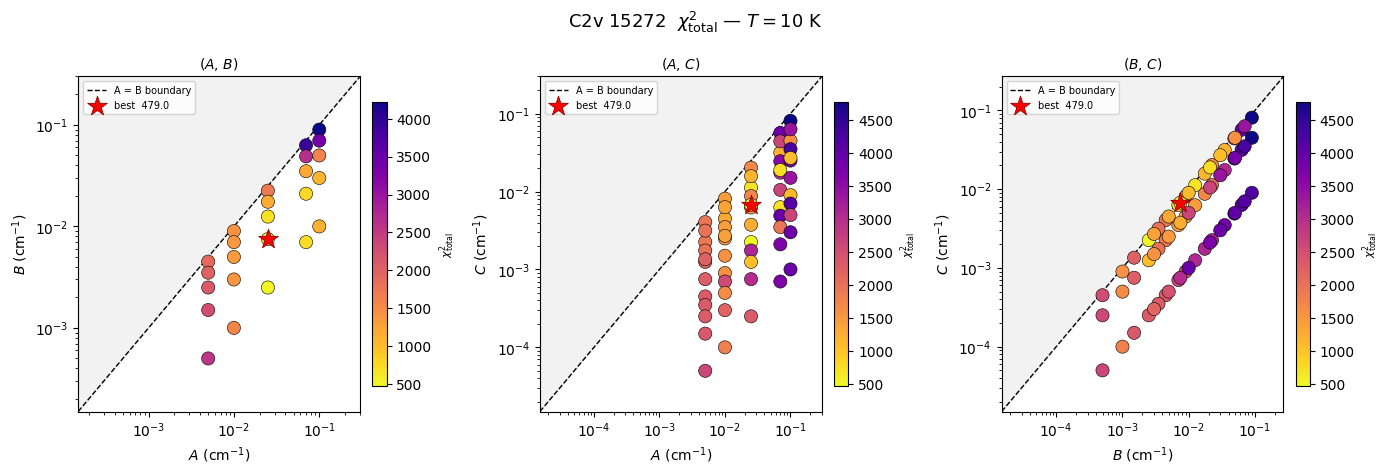

In [49]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

plot_chi2 = 'all'
frac = 0.98
# frac = 1.02

def _norm(chi2):
    vmin, vmax = np.nanmin(chi2), np.nanmax(chi2)
    if vmax / max(vmin, 1e-30) > 10:
        return mcolors.LogNorm(vmin=vmin, vmax=vmax)
    return mcolors.Normalize(vmin=vmin, vmax=vmax)


def _add_forbidden(ax, x, y):
    """Shade the forbidden region y >= x on log-log axes."""
    lo = min(x.min(), y.min()) * 0.3
    hi = max(x.max(), y.max()) * 3
    diag = np.logspace(np.log10(lo), np.log10(hi), 400)
    ax.plot(diag, diag, 'k--', lw=1, zorder=2, label='A = B boundary')
    ax.fill_between(diag, diag, hi * 10, color='gray', alpha=0.10, zorder=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)


def plot_row(axes, A, B, C, chi2, chi2_label, cmap='plasma_r'):
    norm = _norm(chi2)
    good = np.isfinite(chi2)
    pairs = [
        (axes[0], A, B, r'$A$ (cm$^{-1}$)', r'$B$ (cm$^{-1}$)', '($A$, $B$)'),
        (axes[1], A, C, r'$A$ (cm$^{-1}$)', r'$C$ (cm$^{-1}$)', '($A$, $C$)'),
        (axes[2], B, C, r'$B$ (cm$^{-1}$)', r'$C$ (cm$^{-1}$)', '($B$, $C$)'),
    ]
    scatters = []
    for ax, x, y, xl, yl, title in pairs:
        _add_forbidden(ax, x[good], y[good])

        sc = ax.scatter(x[good], y[good], c=chi2[good], cmap=cmap, norm=norm,
                        s=90, edgecolors='k', linewidths=0.4, zorder=3)
        scatters.append(sc)

        ibest = np.nanargmin(chi2)
        ax.scatter(x[ibest], y[ibest], marker='*', s=220, c='red',
                   edgecolors='darkred', linewidths=0.6, zorder=5,
                   label=f'best  {chi2[ibest]:.1f}')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(xl, fontsize=10)
        ax.set_ylabel(yl, fontsize=10)
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=7, loc='upper left')
        cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cb.set_label(chi2_label, fontsize=8)
    return scatters

def _marginal_min(x, y, chi2):
    """Return unique (x, y) pairs with minimum chi2 over the third dimension."""
    # Use rounded log-values as keys to handle float precision
    best = {}
    for xi, yi, c in zip(x, y, chi2):
        if not np.isfinite(c):
            continue
        key = (round(np.log10(xi), 8), round(np.log10(yi), 8))
        if key not in best or c < best[key][2]:
            best[key] = (xi, yi, c)
    vals = np.array(list(best.values()))
    return vals[:, 0], vals[:, 1], vals[:, 2]


def plot_row(axes, A, B, C, chi2, chi2_label, cmap='plasma_r'):
    projections = [
        (axes[0], A, B, r'$A$ (cm$^{-1}$)', r'$B$ (cm$^{-1}$)', '($A$, $B$)'),
        (axes[1], A, C, r'$A$ (cm$^{-1}$)', r'$C$ (cm$^{-1}$)', '($A$, $C$)'),
        (axes[2], B, C, r'$B$ (cm$^{-1}$)', r'$C$ (cm$^{-1}$)', '($B$, $C$)'),
    ]
    scatters = []
    for ax, x_all, y_all, xl, yl, title in projections:
        # Marginalize over the third constant: keep min chi2 at each (x, y) pair
        x, y, c2 = _marginal_min(x_all, y_all, chi2)
        norm = _norm(c2)

        _add_forbidden(ax, x, y)

        sc = ax.scatter(x, y, c=c2, cmap=cmap, norm=norm,
                        s=90, edgecolors='k', linewidths=0.4, zorder=3)
        scatters.append(sc)

        ibest = np.argmin(c2)
        ax.scatter(x[ibest], y[ibest], marker='*', s=220, c='red',
                   edgecolors='darkred', linewidths=0.6, zorder=5,
                   label=f'best  {c2[ibest]:.1f}')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(xl, fontsize=10)
        ax.set_ylabel(yl, fontsize=10)
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=7, loc='upper left')
        cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cb.set_label(chi2_label, fontsize=8)
    return scatters




T = 10
load_npz_name = f'grid_search_C2v_15272_frac{frac}.npz'
d = np.load(load_npz_name)
plot_chi2 = 'total'
savefig = False

T_arr   = d['T']
A_arr   = d['A']
Bf_arr  = d['Bf']
Cf_arr  = d['Cf']
c2_dir  = d['chi2_direct']
c2_dT   = d['chi2_dT']
c2_tot  = d['chi2_total']

B_arr = Bf_arr * A_arr
C_arr = Cf_arr * B_arr

T_vals = np.unique(T_arr)
if T is None:
    T_pick = T_vals[0]
    print(f"No --T supplied; using T = {T_pick:.0f} K.  "
          f"Available: {T_vals.tolist()}")
else:
    T_pick = T_vals[np.argmin(np.abs(T_vals - T))]
    print(f"Using T = {T_pick:.0f} K")

mask = T_arr == T_pick
A, B, C = A_arr[mask], B_arr[mask], C_arr[mask]
sets = {
    'direct': (c2_dir[mask],  r'$\chi^2_\mathrm{direct}$'),
    'dT':     (c2_dT[mask],   r'$\chi^2_\mathrm{dT}$'),
    'total':  (c2_tot[mask],  r'$\chi^2_\mathrm{total}$'),
}

if plot_chi2 == 'all':
    keys = ['direct', 'dT', 'total']
    fig, axes = plt.subplots(3, 3, figsize=(14, 13))
    fig.suptitle(f'C2v 15272 — $T = {T_pick:.0f}$ K', fontsize=13, y=1.01)
    for row, key in enumerate(keys):
        chi2, lbl = sets[key]
        plot_row(axes[row], A, B, C, chi2, lbl)
else:
    chi2, lbl = sets[plot_chi2]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
    fig.suptitle(f'C2v 15272  {lbl} — $T = {T_pick:.0f}$ K', fontsize=13)
    plot_row(axes, A, B, C, chi2, lbl)

plt.tight_layout()
tag = f'T{T_pick:.0f}_{plot_chi2}'
out = str(REPO_ROOT + f'/figs/chi2_landscape_C2v_15272_{tag}.png')
if savefig:
    plt.savefig(out, dpi=200, bbox_inches='tight')
    print(f'Saved {out}')
plt.show()


  loaded grid_search_C2v_15272_frac0.95.npz: 300 pts
  loaded grid_search_C2v_15272_frac0.98.npz: 300 pts
  loaded grid_search_C2v_15272_frac0.99.npz: 300 pts
  loaded grid_search_C2v_15272_frac1.0.npz: 300 pts
  loaded grid_search_C2v_15272_frac1.01.npz: 300 pts
  loaded grid_search_C2v_15272_frac1.02.npz: 300 pts
  loaded grid_search_C2v_15272_frac1.05.npz: 300 pts
total usable points: 2100
  T=5, frac=0.950:     75 pts, min chi^2 = 201.15
  T=5, frac=0.980:     75 pts, min chi^2 = 162.35
  T=5, frac=0.990:     75 pts, min chi^2 = 201.12
  T=5, frac=1.000:     75 pts, min chi^2 = 238.62
  T=5, frac=1.010:     75 pts, min chi^2 = 256.56
  T=5, frac=1.020:     75 pts, min chi^2 = 274.63
  T=5, frac=1.050:     75 pts, min chi^2 = 462.31
  T=10, frac=0.950:     75 pts, min chi^2 = 488.98
  T=10, frac=0.980:     75 pts, min chi^2 = 239.52
  T=10, frac=0.990:     75 pts, min chi^2 = 141.52
  T=10, frac=1.000:     75 pts, min chi^2 = 156.92
  T=10, frac=1.010:     75 pts, min chi^2 = 189.48

/tmp/ipykernel_196248/383486061.py:121: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(cube, axis=drop)


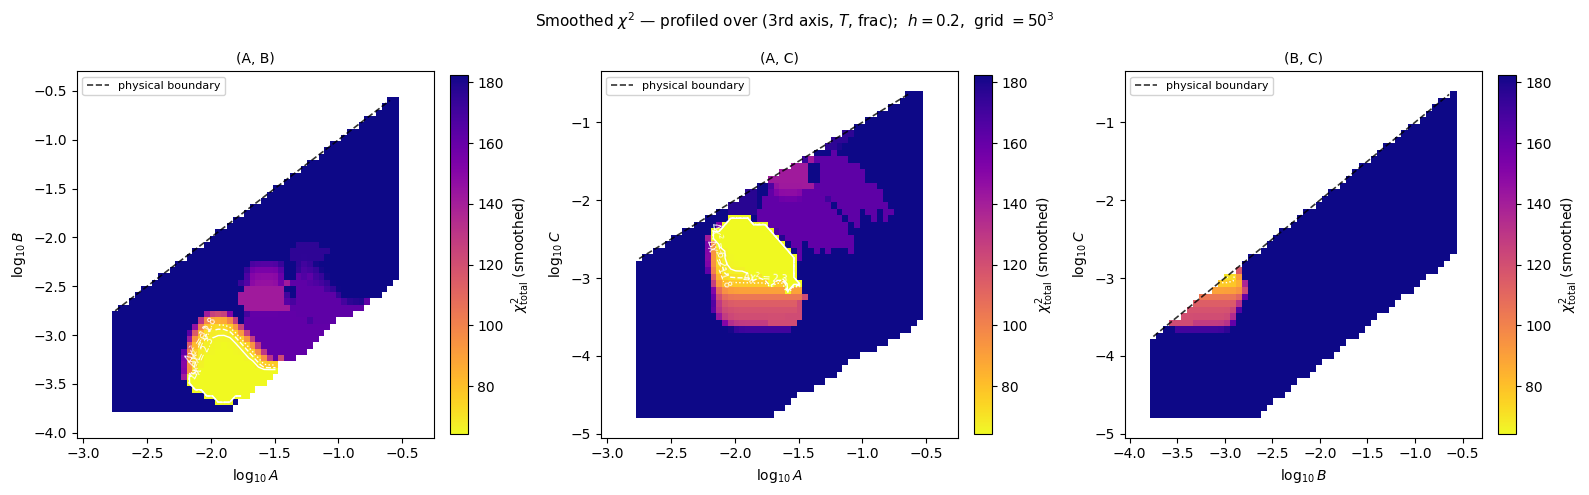

In [50]:
"""
End-to-end smoothed chi^2 visualization over (logA, logB, logC, T, frac).

Pipeline:
  1) Load all per-frac npz files into one flat dataset.
  2) For each discrete (T, frac) slice, build a 3D Nadaraya-Watson
     kernel regression in z-scored (logA, logB, logC) coords.
  3) Evaluate every slice on a common 3D eval grid -> 5D chi^2 cube.
  4) Project to 2D by min-profile over the third spatial axis + T + frac.
  5) Plot with explicit Delta-chi^2 contours; mask the forbidden region.
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix

# ---- config ----------------------------------------------------------------
FRACS     = [0.95, 0.98, 0.99, 1.0, 1.01, 1.02, 1.05]
NPZ_FMT   = 'grid_search_C2v_15272_frac{}.npz'
CHI2_KEY  = 'chi2_total'

H         = 0.2   # bandwidth in z-scored coords (try 0.25 - 0.6)
R_CUT     = 6   # kernel truncation in units of H (3.5 -> ~exp(-6) tail)
N_GRID    = 50     # eval grid resolution per spatial axis
MIN_PTS   = 20     # skip (T, frac) slices with fewer training points

# ---- 1) load all per-frac files -------------------------------------------
records = []
for f in FRACS:
    path = Path(NPZ_FMT.format(f))
    if not path.exists():
        print(f'  skip {path.name} (not found)')
        continue
    d  = np.load(path)
    A, Bf, Cf, T, c2 = d['A'], d['Bf'], d['Cf'], d['T'], d[CHI2_KEY]
    B  = Bf * A
    C  = Cf * B
    
    records.append(np.column_stack([
        np.log10(A), np.log10(B), np.log10(C),
        T.astype(float), np.full_like(A, f, dtype=float), c2/2,
    ]))
    print(f'  loaded {path.name}: {len(A)} pts')

if not records:
    raise SystemExit('no data found')

D = np.vstack(records)
D = D[np.isfinite(D[:, 5])]
logA, logB, logC, T_arr, frac_arr, chi2 = D.T
print(f'total usable points: {len(D)}')

# ---- 2) Nadaraya-Watson smoother (batched, sparse) ------------------------
class NW3D:
    """Gaussian-kernel regression in 3D z-scored coords, batched via KDTree."""
    def __init__(self, X, y, h=0.2, r_cut=3.5):
        self.mu, self.sd = X.mean(0), X.std(0)
        self.sd = np.where(self.sd > 0, self.sd, 1.0)
        self.Xn = (X - self.mu) / self.sd
        self.y  = np.asarray(y, dtype=float)
        self.tree = cKDTree(self.Xn)
        self.h, self.r_cut = float(h), float(r_cut) * float(h)

    def __call__(self, X_query):
        Qn = (X_query - self.mu) / self.sd
        S  = cKDTree(Qn).sparse_distance_matrix(
                self.tree, max_distance=self.r_cut, output_type='coo_matrix')
        w  = np.exp(-0.5 * (S.data / self.h) ** 2)
        W  = csr_matrix((w, (S.row, S.col)), shape=S.shape)
        num = W @ self.y
        den = np.asarray(W.sum(axis=1)).ravel()
        out = np.full(len(Qn), np.nan)
        out[den > 0] = num[den > 0] / den[den > 0]
        return out

# ---- 3) build evaluation grid + smoothed 5D cube --------------------------

stretch = 0.3
f0 = 1.5
    
gA = np.linspace(logA.min() - f0*stretch, logA.max() + f0*stretch, N_GRID)
gB = np.linspace(logB.min() - f0*stretch, logB.max() + f0*stretch, N_GRID)
gC = np.linspace(logC.min() - f0*stretch, logC.max() + f0*stretch, N_GRID)
GA, GB, GC = np.meshgrid(gA, gB, gC, indexing='ij')
G3 = np.column_stack([GA.ravel(), GB.ravel(), GC.ravel()])

T_vals    = np.unique(T_arr)
# T_vals    = np.array([5])

frac_vals = np.unique(frac_arr)
cube = np.full((N_GRID, N_GRID, N_GRID, len(T_vals), len(frac_vals)), np.nan)

# right after the (T, frac) loop that fills `cube`, before any projection:
GA3, GB3, GC3 = np.meshgrid(gA, gB, gC, indexing='ij')
unphysical = (GB3 > GA3) | (GC3 > GB3)        # shape (N_GRID, N_GRID, N_GRID)
cube[unphysical] = np.nan                      # broadcasts across (T, frac) axes

for it, t in enumerate(T_vals):
    for ifr, fr in enumerate(frac_vals):
        m = (T_arr == t) & (frac_arr == fr)
        if m.sum() < MIN_PTS:
            print(f'  skip T={t:.0f} frac={fr:.3f} ({m.sum()} pts)')
            continue
        sm = NW3D(np.column_stack([logA[m], logB[m], logC[m]]),
                  chi2[m], h=H, r_cut=R_CUT)
        cube[..., it, ifr] = sm(G3).reshape(N_GRID, N_GRID, N_GRID)
        print(f'  T={t:.0f}, frac={fr:.3f}: {m.sum():>6d} pts, '
              f'min chi^2 = {np.nanmin(cube[..., it, ifr]):.2f}')

chi2_min = float(np.nanmin(cube))
bi = np.unravel_index(np.nanargmin(cube), cube.shape)
print(f'\nGlobal smoothed min chi^2 = {chi2_min:.2f}')
print(f'at  log10(A,B,C) = ({gA[bi[0]]:.4f}, {gB[bi[1]]:.4f}, {gC[bi[2]]:.4f})'
      f'  T={T_vals[bi[3]]:.0f}  frac={frac_vals[bi[4]]:.3f}')

# ---- 4) min-profile to 2D -------------------------------------------------
def project(cube, keep):
    drop = tuple(d for d in range(cube.ndim) if d not in keep)
    return np.nanmin(cube, axis=drop)

proj_AB = project(cube, (0, 1))   # min over C, T, frac
proj_AC = project(cube, (0, 2))   # min over B, T, frac
proj_BC = project(cube, (1, 2))   # min over A, T, frac

# ---- 5) plot --------------------------------------------------------------
def plot_panel(ax, x, y, Z, xlabel, ylabel, title, chi2_min,
               levels_dchi2=(2.30, 6.18, 11.83)):
    Y, X = np.meshgrid(y, x, indexing='ij')
    Zm = Z.T.copy()
    Zm[Y > X] = np.nan                 # mask physically forbidden region

    pcm = ax.pcolormesh(
        x, y, Zm, shading='auto', cmap='plasma_r',
        norm=mcolors.Normalize(vmin=chi2_min,
                               vmax=chi2_min + 10 * max(levels_dchi2)),
    )
    cs = ax.contour(
        x, y, Zm,
        levels=[chi2_min + d for d in levels_dchi2],
        colors='white', linewidths=1.0, linestyles=['-', '--', ':'],
    )
    ax.clabel(cs,
              fmt={lv: rf'$\Delta\chi^2={d:.1f}$'
                   for lv, d in zip(cs.levels, levels_dchi2)},
              inline=True, fontsize=7)

    lo = max(x.min(), y.min())
    hi = min(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.8,
            label='physical boundary')

#     if np.any(np.isfinite(Zm)):
#         b = np.unravel_index(np.nanargmin(Zm), Zm.shape)
#         ax.scatter(x[b[1]], y[b[0]], marker='*', s=240, c='red',
#                    edgecolor='darkred', lw=0.8, zorder=5,
#                    label=fr'min $\chi^2$ = {Zm[b]:.1f}')

    ax.set_xlim(x.min()-stretch, x.max()+stretch)
    ax.set_ylim(y.min()-stretch, y.max()+stretch)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.85)
    plt.colorbar(pcm, ax=ax, label=r'$\chi^2_{\rm total}$ (smoothed)',
                 fraction=0.046, pad=0.04)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(r'Smoothed $\chi^2$ — profiled over (3rd axis, $T$, frac);  '
             rf'$h={H}$,  grid $={N_GRID}^3$', fontsize=11)
plot_panel(axes[0], gA, gB, proj_AB,
           r'$\log_{10} A$', r'$\log_{10} B$', '(A, B)', chi2_min)
plot_panel(axes[1], gA, gC, proj_AC,
           r'$\log_{10} A$', r'$\log_{10} C$', '(A, C)', chi2_min)
plot_panel(axes[2], gB, gC, proj_BC,
           r'$\log_{10} B$', r'$\log_{10} C$', '(B, C)', chi2_min)
plt.tight_layout()
plt.show()

  loaded grid_search_C2v_15272_frac0.95.npz: 300 pts
  loaded grid_search_C2v_15272_frac0.98.npz: 300 pts
  loaded grid_search_C2v_15272_frac0.99.npz: 300 pts
total usable points: 900
  T=5, frac=0.950:     75 pts, min chi^2 = 201.15
  T=5, frac=0.980:     75 pts, min chi^2 = 162.35
  T=5, frac=0.990:     75 pts, min chi^2 = 201.12
  T=10, frac=0.950:     75 pts, min chi^2 = 488.98
  T=10, frac=0.980:     75 pts, min chi^2 = 239.52
  T=10, frac=0.990:     75 pts, min chi^2 = 141.52
  T=15, frac=0.950:     75 pts, min chi^2 = 753.34
  T=15, frac=0.980:     75 pts, min chi^2 = 304.55
  T=15, frac=0.990:     75 pts, min chi^2 = 193.76
  T=40, frac=0.950:     75 pts, min chi^2 = 1230.41
  T=40, frac=0.980:     75 pts, min chi^2 = 579.57
  T=40, frac=0.990:     75 pts, min chi^2 = 315.54

Global smoothed min chi^2 = 141.52
at  log10(A,B,C) = (-1.7283, -2.5399, -1.5547)  T=10  frac=0.990


/tmp/ipykernel_196248/3308768689.py:118: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(cube, axis=drop)


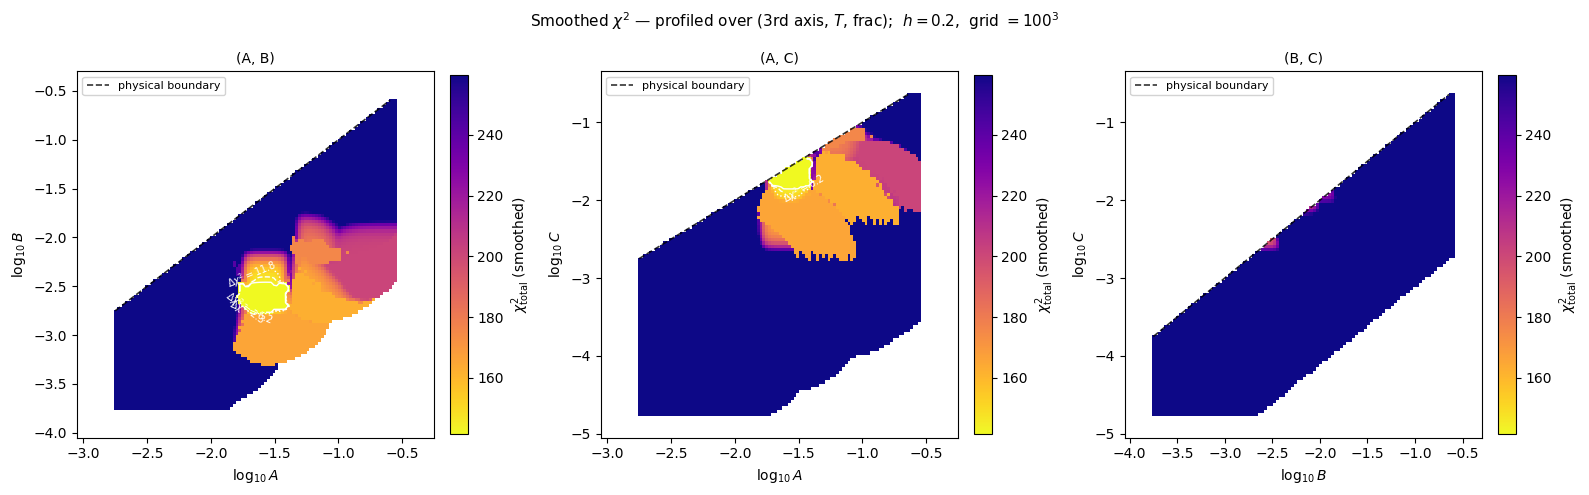

  loaded grid_search_C2v_15272_frac1.01.npz: 300 pts
  loaded grid_search_C2v_15272_frac1.02.npz: 300 pts
  loaded grid_search_C2v_15272_frac1.05.npz: 300 pts
total usable points: 900
  T=5, frac=1.010:     75 pts, min chi^2 = 256.56
  T=5, frac=1.020:     75 pts, min chi^2 = 274.63
  T=5, frac=1.050:     75 pts, min chi^2 = 462.31
  T=10, frac=1.010:     75 pts, min chi^2 = 189.48
  T=10, frac=1.020:     75 pts, min chi^2 = 320.26
  T=10, frac=1.050:     75 pts, min chi^2 = 796.51
  T=15, frac=1.010:     75 pts, min chi^2 = 241.90
  T=15, frac=1.020:     75 pts, min chi^2 = 401.53
  T=15, frac=1.050:     75 pts, min chi^2 = 1076.79
  T=40, frac=1.010:     75 pts, min chi^2 = 296.67
  T=40, frac=1.020:     75 pts, min chi^2 = 740.97
  T=40, frac=1.050:     75 pts, min chi^2 = 1216.43

Global smoothed min chi^2 = 189.48
at  log10(A,B,C) = (-1.7728, -2.4762, -1.4717)  T=10  frac=1.010


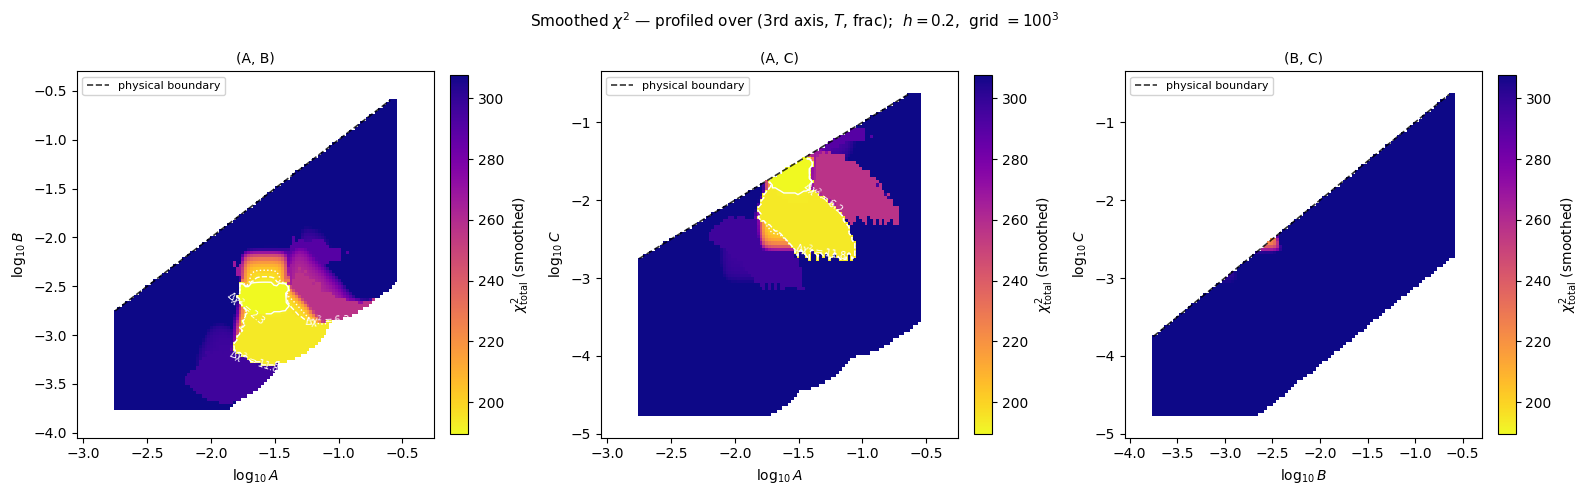

In [47]:
"""
End-to-end smoothed chi^2 visualization over (logA, logB, logC, T, frac).

Pipeline:
  1) Load all per-frac npz files into one flat dataset.
  2) For each discrete (T, frac) slice, build a 3D Nadaraya-Watson
     kernel regression in z-scored (logA, logB, logC) coords.
  3) Evaluate every slice on a common 3D eval grid -> 5D chi^2 cube.
  4) Project to 2D by min-profile over the third spatial axis + T + frac.
  5) Plot with explicit Delta-chi^2 contours; mask the forbidden region.
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix

# ---- config ----------------------------------------------------------------
fracs     = [[0.95, 0.98, 0.99] , [1.01, 1.02, 1.05]]
for FRACS in fracs:
    NPZ_FMT   = 'grid_search_C2v_15272_frac{}.npz'
    CHI2_KEY  = 'chi2_total'

    H         = 0.2   # bandwidth in z-scored coords (try 0.25 - 0.6)
    R_CUT     = 6   # kernel truncation in units of H (3.5 -> ~exp(-6) tail)
    N_GRID    = 100     # eval grid resolution per spatial axis
    MIN_PTS   = 1     # skip (T, frac) slices with fewer training points

    # ---- 1) load all per-frac files -------------------------------------------
    records = []
    for f in FRACS:
        path = Path(NPZ_FMT.format(f))
        if not path.exists():
            print(f'  skip {path.name} (not found)')
            continue
        d  = np.load(path)
        A, Bf, Cf, T, c2 = d['A'], d['Bf'], d['Cf'], d['T'], d[CHI2_KEY]
        B  = Bf * A
        C  = Cf * B
        f0 = 2
#         if T = 10
        records.append(np.column_stack([
            np.log10(A), np.log10(B), np.log10(C),
            T.astype(float), np.full_like(A, f, dtype=float), c2/2,
        ]))
        print(f'  loaded {path.name}: {len(A)} pts')

    if not records:
        raise SystemExit('no data found')

    D = np.vstack(records)
    D = D[np.isfinite(D[:, 5])]
    logA, logB, logC, T_arr, frac_arr, chi2 = D.T
    print(f'total usable points: {len(D)}')

    # ---- 2) Nadaraya-Watson smoother (batched, sparse) ------------------------
    class NW3D:
        """Gaussian-kernel regression in 3D z-scored coords, batched via KDTree."""
        def __init__(self, X, y, h=0.2, r_cut=3.5):
            self.mu, self.sd = X.mean(0), X.std(0)
            self.sd = np.where(self.sd > 0, self.sd, 1.0)
            self.Xn = (X - self.mu) / self.sd
            self.y  = np.asarray(y, dtype=float)
            self.tree = cKDTree(self.Xn)
            self.h, self.r_cut = float(h), float(r_cut) * float(h)

        def __call__(self, X_query):
            Qn = (X_query - self.mu) / self.sd
            S  = cKDTree(Qn).sparse_distance_matrix(
                    self.tree, max_distance=self.r_cut, output_type='coo_matrix')
            w  = np.exp(-0.5 * (S.data / self.h) ** 2)
            W  = csr_matrix((w, (S.row, S.col)), shape=S.shape)
            num = W @ self.y
            den = np.asarray(W.sum(axis=1)).ravel()
            out = np.full(len(Qn), np.nan)
            out[den > 0] = num[den > 0] / den[den > 0]
            return out

    # ---- 3) build evaluation grid + smoothed 5D cube --------------------------

    stretch = 0.3
    f0 = 1.5

    gA = np.linspace(logA.min() - f0*stretch, logA.max() + f0*stretch, N_GRID)
    gB = np.linspace(logB.min() - f0*stretch, logB.max() + f0*stretch, N_GRID)
    gC = np.linspace(logC.min() - f0*stretch, logC.max() + f0*stretch, N_GRID)
    GA, GB, GC = np.meshgrid(gA, gB, gC, indexing='ij')
    G3 = np.column_stack([GA.ravel(), GB.ravel(), GC.ravel()])

    T_vals    = np.unique(T_arr)
    # T_vals    = np.array([5])

    frac_vals = np.unique(frac_arr)
    cube = np.full((N_GRID, N_GRID, N_GRID, len(T_vals), len(frac_vals)), np.nan)

    for it, t in enumerate(T_vals):
        for ifr, fr in enumerate(frac_vals):
            m = (T_arr == t) & (frac_arr == fr)
            if m.sum() < MIN_PTS:
                print(f'  skip T={t:.0f} frac={fr:.3f} ({m.sum()} pts)')
                continue
            sm = NW3D(np.column_stack([logA[m], logB[m], logC[m]]),
                      chi2[m], h=H, r_cut=R_CUT)
            cube[..., it, ifr] = sm(G3).reshape(N_GRID, N_GRID, N_GRID)
            print(f'  T={t:.0f}, frac={fr:.3f}: {m.sum():>6d} pts, '
                  f'min chi^2 = {np.nanmin(cube[..., it, ifr]):.2f}')

    chi2_min = float(np.nanmin(cube))
    bi = np.unravel_index(np.nanargmin(cube), cube.shape)
    print(f'\nGlobal smoothed min chi^2 = {chi2_min:.2f}')
    print(f'at  log10(A,B,C) = ({gA[bi[0]]:.4f}, {gB[bi[1]]:.4f}, {gC[bi[2]]:.4f})'
          f'  T={T_vals[bi[3]]:.0f}  frac={frac_vals[bi[4]]:.3f}')

    # ---- 4) min-profile to 2D -------------------------------------------------
    def project(cube, keep):
        drop = tuple(d for d in range(cube.ndim) if d not in keep)
        return np.nanmin(cube, axis=drop)

    proj_AB = project(cube, (0, 1))   # min over C, T, frac
    proj_AC = project(cube, (0, 2))   # min over B, T, frac
    proj_BC = project(cube, (1, 2))   # min over A, T, frac

    # ---- 5) plot --------------------------------------------------------------
    def plot_panel(ax, x, y, Z, xlabel, ylabel, title, chi2_min,
                   levels_dchi2=(2.30, 6.18, 11.83)):
        Y, X = np.meshgrid(y, x, indexing='ij')
        Zm = Z.T.copy()
        Zm[Y > X] = np.nan                 # mask physically forbidden region

        pcm = ax.pcolormesh(
            x, y, Zm, shading='auto', cmap='plasma_r',
            norm=mcolors.Normalize(vmin=chi2_min,
                                   vmax=chi2_min + 10 * max(levels_dchi2)),
        )
        cs = ax.contour(
            x, y, Zm,
            levels=[chi2_min + d for d in levels_dchi2],
            colors='white', linewidths=1.0, linestyles=['-', '--', ':'],
        )
        ax.clabel(cs,
                  fmt={lv: rf'$\Delta\chi^2={d:.1f}$'
                       for lv, d in zip(cs.levels, levels_dchi2)},
                  inline=True, fontsize=7)

        lo = max(x.min(), y.min())
        hi = min(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.8,
                label='physical boundary')

    #     if np.any(np.isfinite(Zm)):
    #         b = np.unravel_index(np.nanargmin(Zm), Zm.shape)
    #         ax.scatter(x[b[1]], y[b[0]], marker='*', s=240, c='red',
    #                    edgecolor='darkred', lw=0.8, zorder=5,
    #                    label=fr'min $\chi^2$ = {Zm[b]:.1f}')

        ax.set_xlim(x.min()-stretch, x.max()+stretch)
        ax.set_ylim(y.min()-stretch, y.max()+stretch)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(title, fontsize=10)
        ax.legend(loc='upper left', fontsize=8, framealpha=0.85)
        plt.colorbar(pcm, ax=ax, label=r'$\chi^2_{\rm total}$ (smoothed)',
                     fraction=0.046, pad=0.04)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(r'Smoothed $\chi^2$ — profiled over (3rd axis, $T$, frac);  '
                 rf'$h={H}$,  grid $={N_GRID}^3$', fontsize=11)
    plot_panel(axes[0], gA, gB, proj_AB,
               r'$\log_{10} A$', r'$\log_{10} B$', '(A, B)', chi2_min)
    plot_panel(axes[1], gA, gC, proj_AC,
               r'$\log_{10} A$', r'$\log_{10} C$', '(A, C)', chi2_min)
    plot_panel(axes[2], gB, gC, proj_BC,
               r'$\log_{10} B$', r'$\log_{10} C$', '(B, C)', chi2_min)
    plt.tight_layout()
    plt.show()